In [2]:
# Retail Demand Forecasting & Inventory Optimization
# Notebook 01: Exploratory Data Analysis (EDA)

print("Retail Demand Forecasting & Inventory Optimization")
print("Exploratory Data Analysis")

Retail Demand Forecasting & Inventory Optimization
Exploratory Data Analysis


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

In [5]:
# Project root
PROJECT_ROOT = Path("..")

# Processed dataset
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "clean_train.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 248,690
Columns: 8


In [6]:
df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,demand,date
0,FOODS_1_021_CA_1_evaluation,FOODS_1_021,FOODS_1,FOODS,CA_1,CA,0,2011-01-02
1,FOODS_1_021_CA_1_evaluation,FOODS_1_021,FOODS_1,FOODS,CA_1,CA,0,2011-01-03
2,FOODS_1_021_CA_1_evaluation,FOODS_1_021,FOODS_1,FOODS,CA_1,CA,0,2011-01-04
3,FOODS_1_021_CA_1_evaluation,FOODS_1_021,FOODS_1,FOODS,CA_1,CA,0,2011-01-05
4,FOODS_1_021_CA_1_evaluation,FOODS_1_021,FOODS_1,FOODS,CA_1,CA,0,2011-01-06


In [7]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

Dataset Shape:
(248690, 8)

Column Names:
['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'demand', 'date']

Data Types:


id          object
item_id     object
dept_id     object
cat_id      object
store_id    object
state_id    object
demand       int64
date        object
dtype: object

In [8]:
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "column": missing_values.index,
    "missing_values": missing_values.values,
    "missing_percentage": (
        missing_values.values / len(df) * 100
    ).round(2)
})

missing_summary = missing_summary.sort_values(
    "missing_values",
    ascending=False
)

display(missing_summary)

,column,missing_values,missing_percentage
0,id,0,0.0
1,item_id,0,0.0
2,dept_id,0,0.0
3,cat_id,0,0.0
4,store_id,0,0.0
5,state_id,0,0.0
6,demand,0,0.0
7,date,0,0.0


In [9]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate records: {duplicate_count:,}")

Duplicate records: 0


In [10]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("Minimum date:", df["date"].min())
print("Maximum date:", df["date"].max())

print("\nInvalid dates:", df["date"].isna().sum())

Minimum date: 2011-01-02 00:00:00
Maximum date: 2016-03-28 00:00:00

Invalid dates: 0


In [11]:
demand_statistics = df["demand"].describe()

display(demand_statistics)

count    248690.000000
mean          0.755591
std           1.933038
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max         183.000000
Name: demand, dtype: float64

In [12]:
negative_demand = (df["demand"] < 0).sum()
zero_demand = (df["demand"] == 0).sum()
positive_demand = (df["demand"] > 0).sum()

print(f"Negative demand records : {negative_demand:,}")
print(f"Zero-demand records     : {zero_demand:,}")
print(f"Positive-demand records : {positive_demand:,}")

print(
    f"\nZero-demand percentage: "
    f"{zero_demand / len(df) * 100:.2f}%"
)

Negative demand records : 0
Zero-demand records     : 172,620
Positive-demand records : 76,070

Zero-demand percentage: 69.41%


In [13]:
summary = {
    "Unique Products": df["item_id"].nunique(),
    "Unique Departments": df["dept_id"].nunique(),
    "Unique Categories": df["cat_id"].nunique(),
    "Unique Stores": df["store_id"].nunique(),
    "Unique States": df["state_id"].nunique()
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

display(summary_df)

,Metric,Value
0,Unique Products,13
1,Unique Departments,7
2,Unique Categories,3
3,Unique Stores,10
4,Unique States,3


In [14]:
daily_demand = (
    df.groupby("date", as_index=False)["demand"]
    .sum()
    .sort_values("date")
)

display(daily_demand.head())

,date,demand
0,2011-01-02,87
1,2011-01-03,71
2,2011-01-04,55
3,2011-01-05,83
4,2011-01-06,55


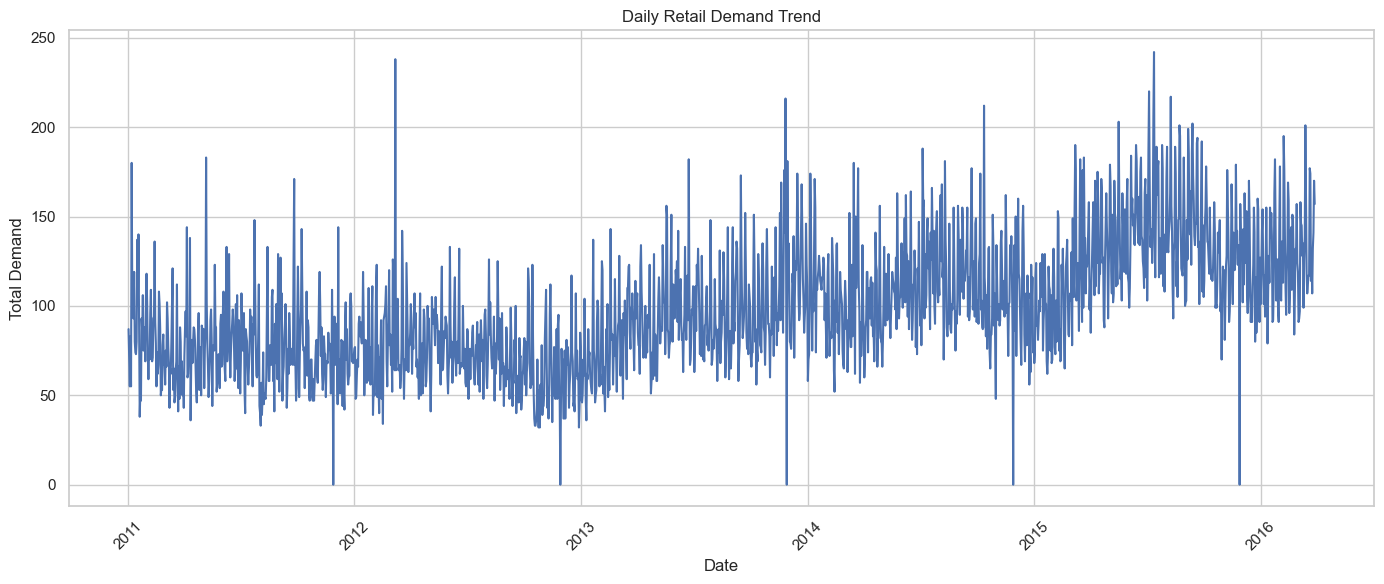

In [15]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_demand["date"],
    daily_demand["demand"],
    linewidth=1.5
)

plt.title("Daily Retail Demand Trend")
plt.xlabel("Date")
plt.ylabel("Total Demand")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [16]:
monthly_demand = (
    df.assign(month=df["date"].dt.to_period("M"))
      .groupby("month", as_index=False)["demand"]
      .sum()
)

monthly_demand["month"] = monthly_demand["month"].astype(str)

display(monthly_demand.head())

,month,demand
0,2011-01,2698
1,2011-02,2229
2,2011-03,2148
3,2011-04,2274
4,2011-05,2472


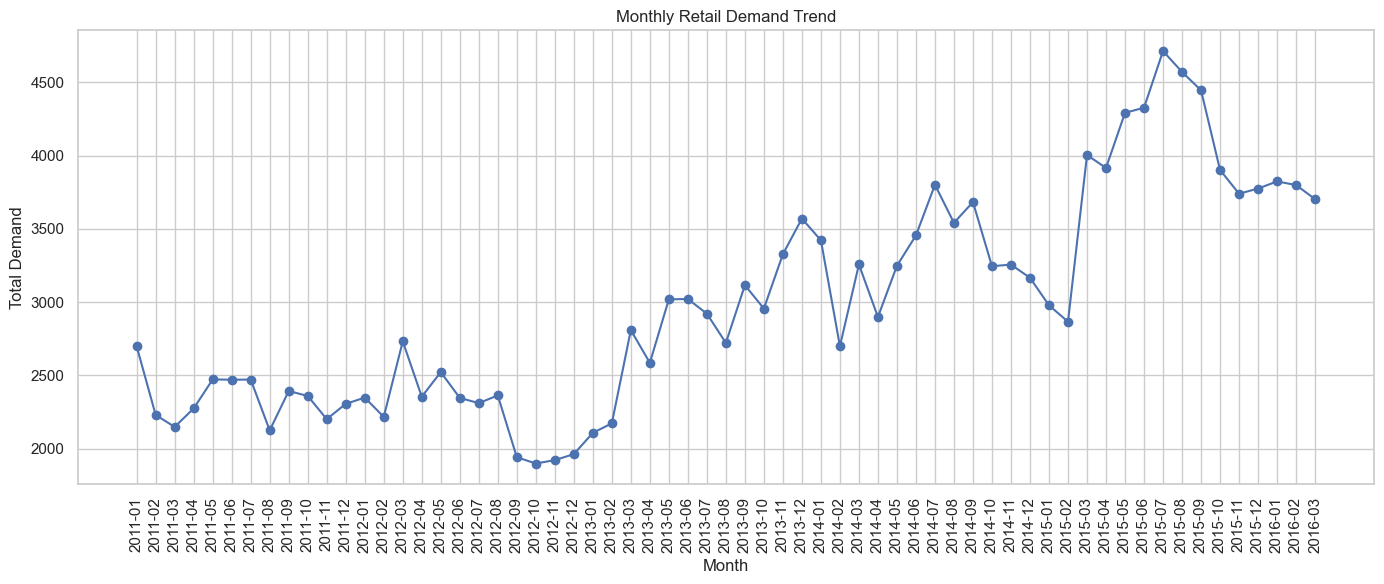

In [17]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_demand["month"],
    monthly_demand["demand"],
    marker="o"
)

plt.title("Monthly Retail Demand Trend")
plt.xlabel("Month")
plt.ylabel("Total Demand")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [18]:
category_demand = (
    df.groupby("cat_id", as_index=False)["demand"]
    .sum()
    .sort_values("demand", ascending=False)
)

display(category_demand)

,cat_id,demand
2,HOUSEHOLD,82790
1,HOBBIES,62021
0,FOODS,43097


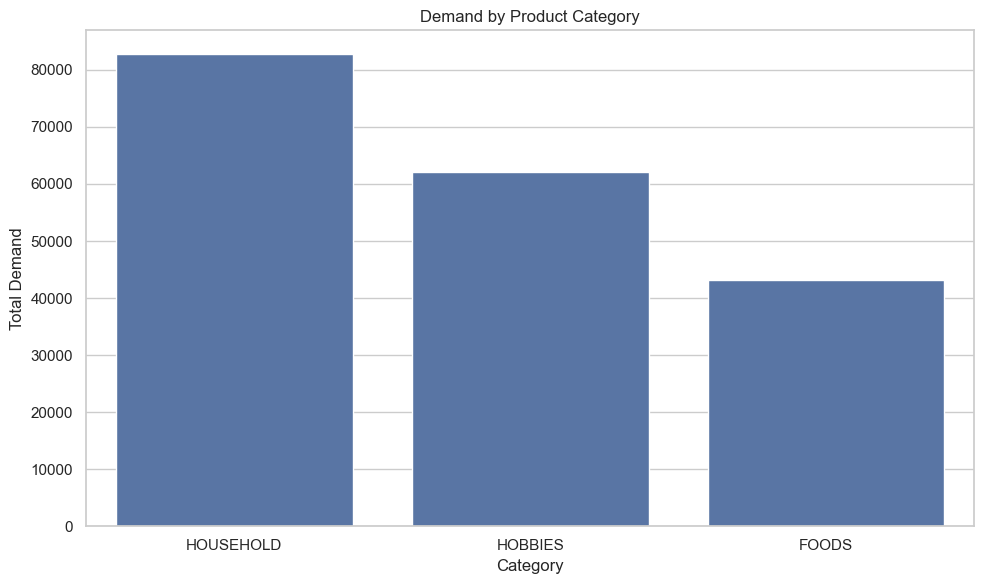

In [19]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_demand,
    x="cat_id",
    y="demand"
)

plt.title("Demand by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Demand")

plt.tight_layout()
plt.show()

In [20]:
product_demand = (
    df.groupby("item_id", as_index=False)["demand"]
    .sum()
    .sort_values("demand", ascending=False)
)

display(product_demand)

,item_id,demand
5,HOBBIES_1_209,49959
10,HOUSEHOLD_1_370,27838
0,FOODS_1_021,27684
8,HOUSEHOLD_1_100,20844
12,HOUSEHOLD_2_442,16273
9,HOUSEHOLD_1_290,13238
1,FOODS_2_035,11099
4,HOBBIES_1_022,7357
11,HOUSEHOLD_1_489,4597
2,FOODS_3_180,2906


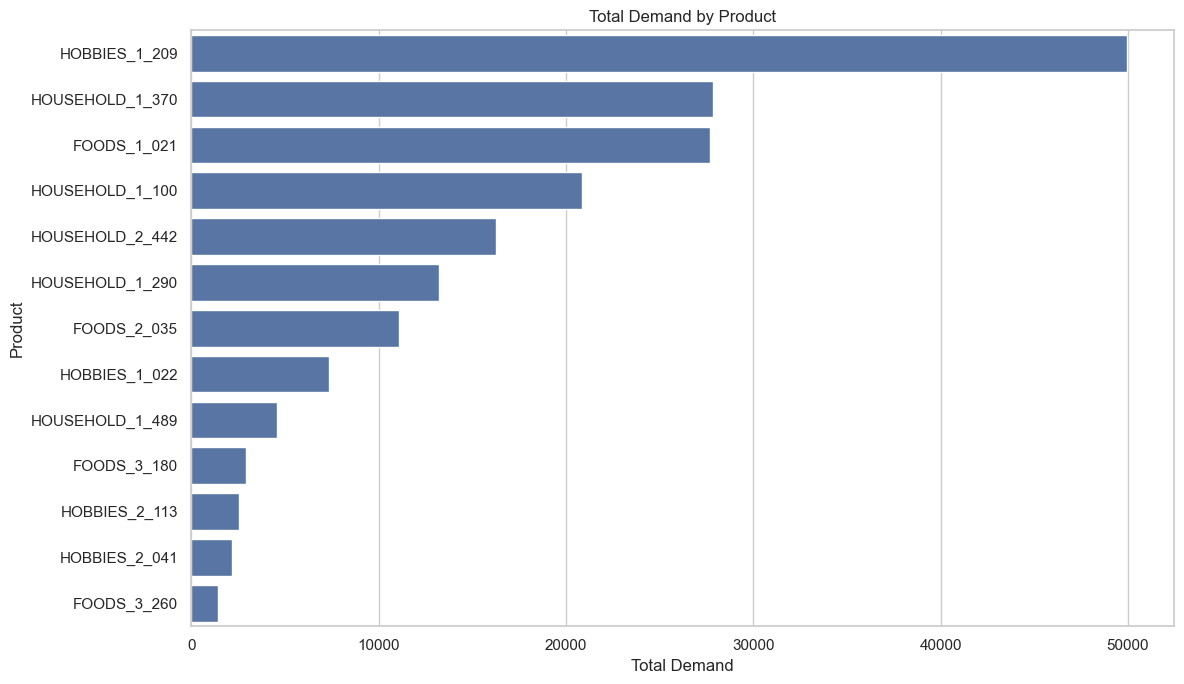

In [21]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=product_demand,
    x="demand",
    y="item_id"
)

plt.title("Total Demand by Product")
plt.xlabel("Total Demand")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [22]:
store_demand = (
    df.groupby("store_id", as_index=False)["demand"]
    .sum()
    .sort_values("demand", ascending=False)
)

display(store_demand)

,store_id,demand
2,CA_3,34170
0,CA_1,25869
1,CA_2,24380
7,WI_1,18510
9,WI_3,16975
5,TX_2,16629
8,WI_2,15314
6,TX_3,13711
4,TX_1,13454
3,CA_4,8896


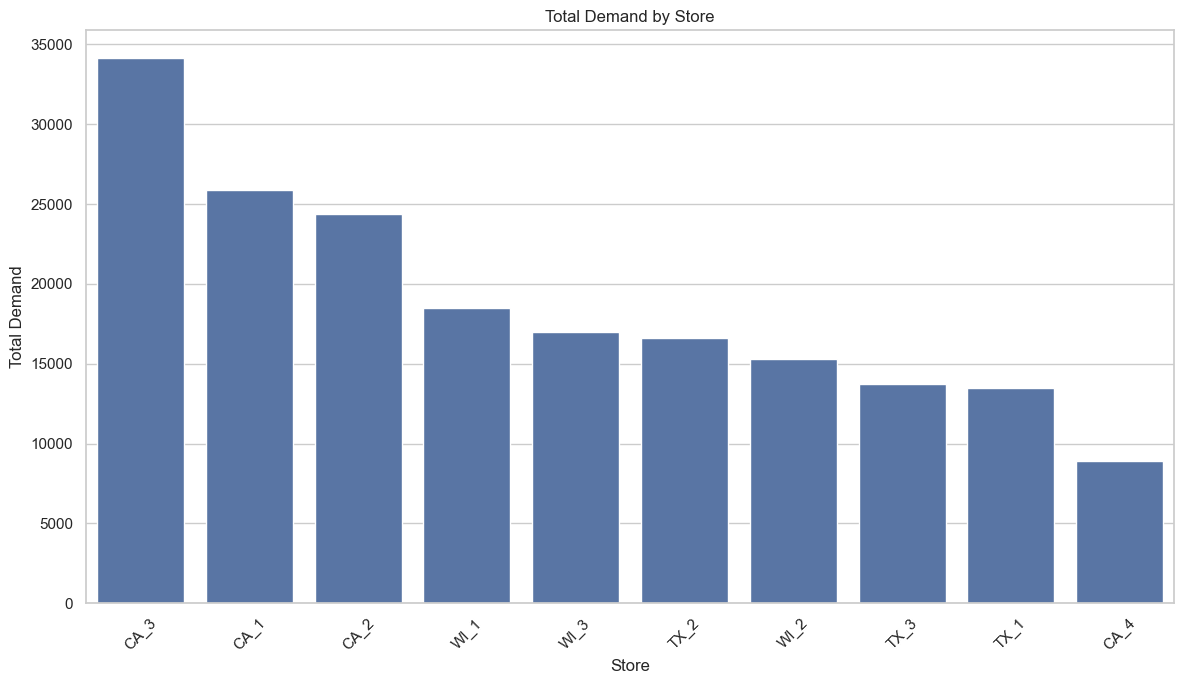

In [23]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=store_demand,
    x="store_id",
    y="demand"
)

plt.title("Total Demand by Store")
plt.xlabel("Store")
plt.ylabel("Total Demand")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

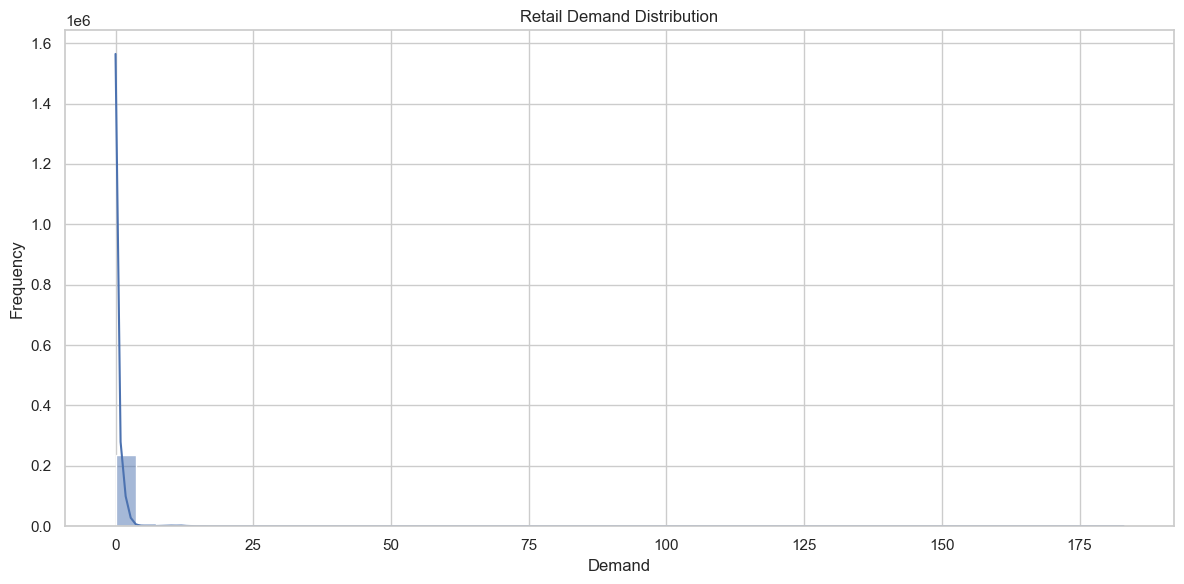

In [24]:
plt.figure(figsize=(12, 6))

sns.histplot(
    df["demand"],
    bins=50,
    kde=True
)

plt.title("Retail Demand Distribution")
plt.xlabel("Demand")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [25]:
weekday_demand = (
    df.assign(
        weekday=df["date"].dt.day_name()
    )
    .groupby("weekday", as_index=False)["demand"]
    .mean()
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_demand["weekday"] = pd.Categorical(
    weekday_demand["weekday"],
    categories=weekday_order,
    ordered=True
)

weekday_demand = weekday_demand.sort_values("weekday")

display(weekday_demand)

,weekday,demand
1,Monday,0.881892
5,Tuesday,0.703438
6,Wednesday,0.657453
4,Thursday,0.637813
0,Friday,0.665286
2,Saturday,0.770921
3,Sunday,0.971084


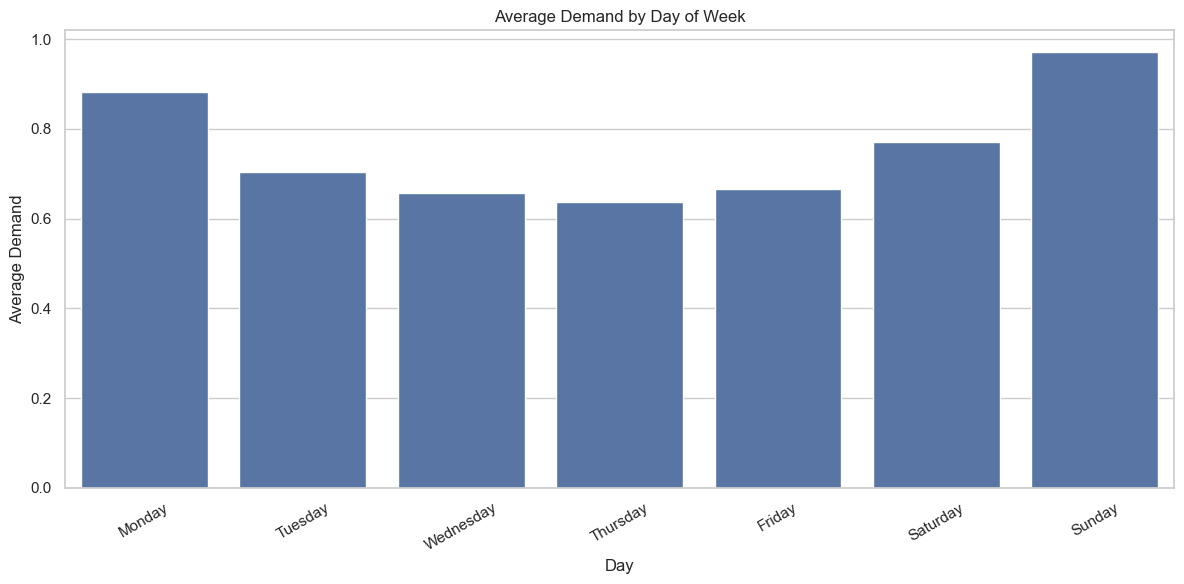

In [26]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=weekday_demand,
    x="weekday",
    y="demand"
)

plt.title("Average Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Demand")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [27]:
product_store_summary = (
    df.groupby(
        ["item_id", "store_id"],
        as_index=False
    )
    .agg(
        total_demand=("demand", "sum"),
        average_demand=("demand", "mean"),
        maximum_demand=("demand", "max"),
        demand_records=("demand", "count")
    )
    .sort_values(
        "total_demand",
        ascending=False
    )
)

display(product_store_summary.head(20))

,item_id,store_id,total_demand,average_demand,maximum_demand,demand_records
52,HOBBIES_1_209,CA_3,12738,6.658651,72,1913
51,HOBBIES_1_209,CA_2,8040,4.202823,54,1913
0,FOODS_1_021,CA_1,7287,3.809200,48,1913
50,HOBBIES_1_209,CA_1,6376,3.332985,43,1913
82,HOUSEHOLD_1_100,CA_3,5526,2.888657,13,1913
7,FOODS_1_021,WI_1,5238,2.738108,29,1913
102,HOUSEHOLD_1_370,CA_3,4980,2.603241,14,1913
55,HOBBIES_1_209,TX_2,4714,2.464192,40,1913
101,HOUSEHOLD_1_370,CA_2,4293,2.244119,15,1913
54,HOBBIES_1_209,TX_1,4158,2.173549,183,1913


In [28]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

correlation_matrix = df[numeric_columns].corr()

display(correlation_matrix)

,demand
demand,1.0


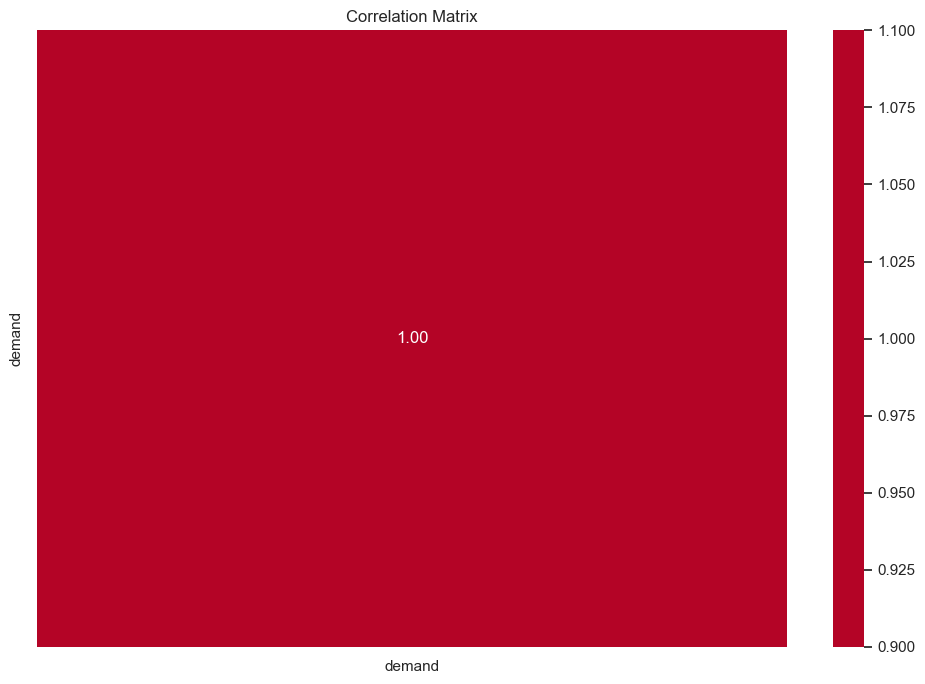

In [29]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()

plt.show()

In [30]:
print("========== EDA SUMMARY ==========")

print(f"Total records       : {len(df):,}")
print(f"Unique products     : {df['item_id'].nunique()}")
print(f"Unique departments  : {df['dept_id'].nunique()}")
print(f"Unique categories   : {df['cat_id'].nunique()}")
print(f"Unique stores       : {df['store_id'].nunique()}")
print(f"Unique states       : {df['state_id'].nunique()}")

print(f"\nDate range:")
print(f"{df['date'].min().date()} → {df['date'].max().date()}")

print(f"\nTotal demand        : {df['demand'].sum():,.2f}")
print(f"Average demand      : {df['demand'].mean():,.2f}")
print(f"Minimum demand      : {df['demand'].min():,.2f}")
print(f"Maximum demand      : {df['demand'].max():,.2f}")

print(
    f"\nZero-demand records : "
    f"{(df['demand'] == 0).sum():,}"
)

print(
    f"Zero-demand %       : "
    f"{(df['demand'] == 0).mean() * 100:.2f}%"
)

========== EDA SUMMARY ==========
Total records       : 248,690
Unique products     : 13
Unique departments  : 7
Unique categories   : 3
Unique stores       : 10
Unique states       : 3

Date range:
2011-01-02 → 2016-03-28

Total demand        : 187,908.00
Average demand      : 0.76
Minimum demand      : 0.00
Maximum demand      : 183.00

Zero-demand records : 172,620
Zero-demand %       : 69.41%


In [31]:
print("""
EDA CONCLUSIONS
---------------

1. The dataset contains historical retail demand records across
   multiple products, categories, stores, and states.

2. Demand varies across products and stores, showing the need
   for product-store level analysis.

3. The dataset contains a substantial number of zero-demand
   observations, which is important when building forecasting models.

4. Daily and monthly demand trends provide the time-series
   structure required for forecasting.

5. Product, category, and store demand summaries provide useful
   information for inventory planning.

6. The cleaned dataset can be used for feature engineering,
   demand forecasting, and inventory optimization.
""")


EDA CONCLUSIONS
---------------

1. The dataset contains historical retail demand records across
   multiple products, categories, stores, and states.

2. Demand varies across products and stores, showing the need
   for product-store level analysis.

3. The dataset contains a substantial number of zero-demand
   observations, which is important when building forecasting models.

4. Daily and monthly demand trends provide the time-series
   structure required for forecasting.

5. Product, category, and store demand summaries provide useful
   information for inventory planning.

6. The cleaned dataset can be used for feature engineering,
   demand forecasting, and inventory optimization.

